In [30]:
import os
import sys
import warnings

os.environ["PYTHONHASHSEED"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append(os.getcwd())
sys.path.append("..")
warnings.filterwarnings("ignore")

In [31]:
import re
import json
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
import tqdm

import tensorflow as tf

from src.classification import load_dataset, set_global_determinism
from models.model import get_classifier

In [32]:
ROOT_PATH = "../results/nm2026_2"
N_CV = 5
N_SEED = 3

MODEL_CONVERTER = {
    "esn": "UniESN",
    "bi_esn": "BiESN",
    "bi_esn2d": "BiESN2D",
}

In [ ]:
def match_dir(dataset: str, model: str, units: int) -> list[str]:
    pattern = os.path.join(ROOT_PATH, f"*_{dataset}_{model}_units-{units}")
    matched_dirs = glob.glob(pattern)
    return matched_dirs[0]


def get_hp(dir_path: str) -> dict:
    json_file = os.path.join(dir_path, "best_param.json")
    with open(json_file, "r") as f:
        data = json.load(f)
    return data["resolved_hyperparams"]


def get_occlusion_sensitivity_map(
    model: tf.keras.Model,
    image: np.ndarray,  # (H, W, C) float32
    class_index: int,
    patch_size: int = 4,
    stride: int = 4,
    batch_size: int = 512,  # ここが重要：VRAM/速度のバランス
    use_logits: bool = True,  # model出力がlogits前提ならTrue
) -> np.ndarray:
    H, W, C = image.shape

    fill_value = float(image.mean())

    # 走査位置を列挙（top/leftの全組み合わせ）
    tops = np.arange(0, H - patch_size + 1, stride)
    lefts = np.arange(0, W - patch_size + 1, stride)
    positions = [(t, l) for t in tops for l in lefts]
    N = len(positions)

    def get_score(imgs: np.ndarray) -> np.ndarray:
        y = model(imgs, training=False)  # (N, K) logits か確率
        if isinstance(y, tf.Tensor):
            y = y.numpy()
        if not use_logits:
            # 出力がlogitsならsoftmaxして確率へ（必要な場合のみ）
            y = tf.nn.softmax(y, axis=-1).numpy()
        return y[:, class_index].astype(np.float32)  # (N,)

    base = float(get_score(image[None, ...])[0])
    print(
        f"Base score: true={class_index}, pred={np.argmax(model(image[None, ...], training=False).numpy())}, score={base:.4f}"
    )

    heat_map = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    # チャンクごとに occlusion 画像を作って推論
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        bs = end - start

        occ_imgs = np.repeat(image[None, ...], bs, axis=0)  # (bs, H, W, C)

        # 各画像に異なる位置のマスクを適用
        for k, (top, left) in enumerate(positions[start:end]):
            occ_imgs[k, top : top + patch_size, left : left + patch_size, :] = fill_value

        scores = get_score(occ_imgs)  # (bs,)
        delta = (base - scores).astype(np.float32)  # (bs,)

        # heatmapに位置対応で反映
        for k, (top, left) in enumerate(positions[start:end]):
            d = delta[k]
            heat_map[top : top + patch_size, left : left + patch_size] += d
            count_map[top : top + patch_size, left : left + patch_size] += 1.0

    heat_map = heat_map / np.maximum(count_map, 1.0)

    return heat_map


def pick_k_images_per_class(x: np.ndarray, y: np.ndarray, k: int, num_classes: int) -> list[tuple[np.ndarray, int]]:
    # [2 1 5 0 1 2 0 1 0 4]
    TRUE_LABELS = [2, 1, 5, 0, 1, 2, 0, 1, 0, 4]
    np.random.seed(0)
    selected = []
    for class_idx in range(num_classes):
        indices = np.where(y == class_idx)[0]
        if len(indices) == 0:
            continue
        chosen_indices = np.random.choice(indices, size=min(k, len(indices)), replace=False)
        for i, idx in enumerate(chosen_indices):
            if TRUE_LABELS[class_idx] == i:
                print(f"Class: {class_idx}, True Label: {TRUE_LABELS[class_idx]}, Selected Label: {i}")
                selected.append((x[idx], class_idx))
    return selected


DATA_CONVERTER = {
    "mnist": {
        0: "0",
        1: "1",
        2: "2",
        3: "3",
        4: "4",
        5: "5",
        6: "6",
        7: "7",
        8: "8",
        9: "9",
    },
    "cifar_10": {
        0: "airplane",
        1: "automobile",
        2: "bird",
        3: "cat",
        4: "deer",
        5: "dog",
        6: "frog",
        7: "horse",
        8: "ship",
        9: "truck",
    },
    "stl_10": {
        0: "airplane",
        1: "bird",
        2: "car",
        3: "cat",
        4: "deer",
        5: "dog",
        6: "horse",
        7: "monkey",
        8: "ship",
        9: "truck",
    },
}


def get_model_maps(x_test, y_test_int, num_classes, dataset, best_units, k=1):
    selected_images = pick_k_images_per_class(x_test, y_test_int, k=k, num_classes=num_classes)

    H, W, C = x_test.shape[1:]

    input_imgs = [(DATA_CONVERTER[dataset][class_idx], img) for img, class_idx in selected_images]
    model_maps = {key: [] for key in best_units[dataset].keys()}

    for model_name, units in tqdm.tqdm(best_units[dataset].items()):
        base_dir = match_dir(dataset, model_name, units)

        for img, class_idx in selected_images:
            maps = []
            for ms in range(N_SEED):
                for cv in range(N_CV):
                    print(f"Processing {model_name}, Seed={ms}, CV={cv}...")

                    cv_seed_dir = os.path.join(base_dir, f"cv-{cv}_seed-{ms}")

                    hp = get_hp(cv_seed_dir)
                    weight_file = os.path.join(cv_seed_dir, "model_weights.npz")
                    weight_npz = np.load(weight_file, allow_pickle=True)
                    W_T = weight_npz["W_T"]  # (units, HWC)

                    set_global_determinism(seed=ms)
                    model = get_classifier(
                        input_shape=(H, W, C),
                        num_classes=num_classes,
                        patch_sizes=(hp["patch_h"], hp["patch_w"]),
                        model_type=hp["model_type"],
                        units=hp["units"],
                        connectivity=hp["connectivity"],
                        leaky=hp["leaky"],
                        spectral_radius=hp["spectral_radius"],
                        seed=ms,
                    )
                    model.layers[-1].set_weights([W_T])

                    heat_map = get_occlusion_sensitivity_map(
                        model=model,
                        image=img,
                        class_index=class_idx,
                        patch_size=8,
                        stride=2,
                        batch_size=512,
                        use_logits=True,
                    )
                    maps.append(heat_map)

            model_maps[model_name].append((class_idx, np.mean(maps, axis=0)))

    return input_imgs, model_maps

In [41]:
def get_overlay(img, heat_map, alpha=0.5):
    if img.ndim == 2:  # グレースケールならRGBに変換
        img = np.stack([img] * 3, axis=-1)
    img = img.astype(np.float32)

    # ヒートマップを0-1に正規化
    norm_heat = (heat_map - np.min(heat_map)) / (np.max(heat_map) - np.min(heat_map) + 1e-8)
    norm_heat = np.clip(norm_heat, 0, 1)

    # ヒートマップをカラー化（赤系のカラーマップ）
    cmap = plt.get_cmap("Reds")
    heat_color = cmap(norm_heat)[:, :, :3]  # RGBA -> RGB

    # 元画像とヒートマップを重ねる
    overlay = (1 - alpha) * img + alpha * heat_color
    overlay = np.clip(overlay, 0, 1)

    return overlay

---

In [42]:
# DATASET = "mnist"
DATASET = "cifar_10"
# DATASET = "stl_10"

best_units = {
    "mnist": {"esn": 256, "bi_esn": 512, "bi_esn2d": 512},
    "cifar_10": {"esn": 128, "bi_esn": 128, "bi_esn2d": 256},
    "stl_10": {"esn": 512, "bi_esn": 512, "bi_esn2d": 512},
}

In [43]:
_, _, x_test, y_test_int, num_classes = load_dataset(DATASET)

In [44]:
# from scipy.stats import mode


# # Check
# def ensemble(imgs, model_name, units):
#     N, H, W, C = imgs.shape

#     preds_array = []
#     for ms in tqdm.tqdm(range(N_SEED)):
#         for cv in range(N_CV):
#             # print(f"{model_name} (seed:{ms}, cv:{cv})")

#             base_dir = match_dir(DATASET, model_name, units)
#             cv_seed_dir = os.path.join(base_dir, f"cv-{cv}_seed-{ms}")

#             hp = get_hp(cv_seed_dir)
#             weight_file = os.path.join(cv_seed_dir, "model_weights.npz")
#             weight_npz = np.load(weight_file, allow_pickle=True)
#             W_T = weight_npz["W_T"]  # (units, HWC)

#             set_global_determinism(seed=ms)
#             model = get_classifier(
#                 input_shape=(H, W, C),
#                 num_classes=num_classes,
#                 patch_sizes=(hp["patch_h"], hp["patch_w"]),
#                 model_type=hp["model_type"],
#                 units=hp["units"],
#                 connectivity=hp["connectivity"],
#                 leaky=hp["leaky"],
#                 spectral_radius=hp["spectral_radius"],
#                 seed=ms,
#             )
#             model.layers[-1].set_weights([W_T])

#             preds = model(imgs, training=False).numpy()  # (N, K)
#             preds = np.argmax(preds, axis=-1)  # (N,)
#             preds_array.append(preds)
#     preds_array = np.stack(preds_array, axis=0)  # (N_SEED*N_CV, N)

#     # 多数決で最終予測を決定
#     ensemble_pred = mode(preds_array, axis=0, keepdims=False).mode  # (N,)
#     print(ensemble_pred.shape)

#     return ensemble_pred


# selected_images = pick_k_images_per_class(x_test, y_test_int, k=10, num_classes=10)
# imgs = np.stack([img for img, _ in selected_images], axis=0)  # (N, H, W, C)
# labels = np.array([class_idx for _, class_idx in selected_images])  # (N,)

# y_esn = ensemble(imgs, "esn", best_units[DATASET]["esn"])
# y_bi_esn = ensemble(imgs, "bi_esn", best_units[DATASET]["bi_esn"])
# y_bi_esn2d = ensemble(imgs, "bi_esn2d", best_units[DATASET]["bi_esn2d"])

In [45]:
# stacked = np.stack([labels, y_esn, y_bi_esn, y_bi_esn2d], axis=0)  # (4, N)
# is_equal = np.all(stacked == stacked[0], axis=0)
# is_equal = is_equal.reshape(10, 10)  # (10, 10)
# first_true_idx = np.argmax(is_equal, axis=1)

# print(first_true_idx)

In [46]:
input_imgs, model_maps = get_model_maps(x_test, y_test_int, num_classes, DATASET, best_units, k=10)

Class: 0, True Label: 2, Selected Label: 2
Class: 1, True Label: 1, Selected Label: 1
Class: 2, True Label: 5, Selected Label: 5
Class: 3, True Label: 0, Selected Label: 0
Class: 4, True Label: 1, Selected Label: 1
Class: 5, True Label: 2, Selected Label: 2
Class: 6, True Label: 0, Selected Label: 0
Class: 7, True Label: 1, Selected Label: 1
Class: 8, True Label: 0, Selected Label: 0
Class: 9, True Label: 4, Selected Label: 4


  0%|          | 0/3 [00:00<?, ?it/s]

Processing esn, Seed=0, CV=0...
Base score: true=0, pred=0, score=0.4214
Processing esn, Seed=0, CV=1...
Base score: true=0, pred=0, score=0.4115
Processing esn, Seed=0, CV=2...
Base score: true=0, pred=0, score=0.4151
Processing esn, Seed=0, CV=3...
Base score: true=0, pred=0, score=0.4405
Processing esn, Seed=0, CV=4...
Base score: true=0, pred=0, score=0.4119
Processing esn, Seed=1, CV=0...
Base score: true=0, pred=0, score=0.4538
Processing esn, Seed=1, CV=1...
Base score: true=0, pred=0, score=0.5129
Processing esn, Seed=1, CV=2...
Base score: true=0, pred=0, score=0.4568
Processing esn, Seed=1, CV=3...
Base score: true=0, pred=0, score=0.4703
Processing esn, Seed=1, CV=4...
Base score: true=0, pred=0, score=0.4509
Processing esn, Seed=2, CV=0...
Base score: true=0, pred=0, score=0.4666
Processing esn, Seed=2, CV=1...
Base score: true=0, pred=0, score=0.4051
Processing esn, Seed=2, CV=2...
Base score: true=0, pred=0, score=0.4066
Processing esn, Seed=2, CV=3...
Base score: true=0,

 33%|███▎      | 1/3 [01:46<03:32, 106.11s/it]

Base score: true=9, pred=9, score=0.2971
Processing bi_esn, Seed=0, CV=0...
Base score: true=0, pred=0, score=0.4098
Processing bi_esn, Seed=0, CV=1...
Base score: true=0, pred=0, score=0.3872
Processing bi_esn, Seed=0, CV=2...
Base score: true=0, pred=0, score=0.3770
Processing bi_esn, Seed=0, CV=3...
Base score: true=0, pred=0, score=0.4657
Processing bi_esn, Seed=0, CV=4...
Base score: true=0, pred=0, score=0.4664
Processing bi_esn, Seed=1, CV=0...
Base score: true=0, pred=0, score=0.5382
Processing bi_esn, Seed=1, CV=1...
Base score: true=0, pred=0, score=0.3914
Processing bi_esn, Seed=1, CV=2...
Base score: true=0, pred=0, score=0.4638
Processing bi_esn, Seed=1, CV=3...
Base score: true=0, pred=0, score=0.5099
Processing bi_esn, Seed=1, CV=4...
Base score: true=0, pred=0, score=0.4003
Processing bi_esn, Seed=2, CV=0...
Base score: true=0, pred=0, score=0.4541
Processing bi_esn, Seed=2, CV=1...
Base score: true=0, pred=0, score=0.3982
Processing bi_esn, Seed=2, CV=2...
Base score: 

 67%|██████▋   | 2/3 [05:10<02:43, 163.76s/it]

Processing bi_esn2d, Seed=0, CV=0...
Base score: true=0, pred=0, score=0.3757
Processing bi_esn2d, Seed=0, CV=1...
Base score: true=0, pred=0, score=0.3975
Processing bi_esn2d, Seed=0, CV=2...
Base score: true=0, pred=0, score=0.4297
Processing bi_esn2d, Seed=0, CV=3...
Base score: true=0, pred=0, score=0.4094
Processing bi_esn2d, Seed=0, CV=4...
Base score: true=0, pred=0, score=0.4495
Processing bi_esn2d, Seed=1, CV=0...
Base score: true=0, pred=8, score=0.3970
Processing bi_esn2d, Seed=1, CV=1...
Base score: true=0, pred=0, score=0.4655
Processing bi_esn2d, Seed=1, CV=2...
Base score: true=0, pred=0, score=0.5115
Processing bi_esn2d, Seed=1, CV=3...
Base score: true=0, pred=0, score=0.4096
Processing bi_esn2d, Seed=1, CV=4...
Base score: true=0, pred=0, score=0.4377
Processing bi_esn2d, Seed=2, CV=0...
Base score: true=0, pred=8, score=0.3561
Processing bi_esn2d, Seed=2, CV=1...
Base score: true=0, pred=0, score=0.3767
Processing bi_esn2d, Seed=2, CV=2...
Base score: true=0, pred=8,

100%|██████████| 3/3 [06:47<00:00, 135.76s/it]

Base score: true=9, pred=9, score=0.4171


Class: airplane, Image shape: (32, 32, 3)
-0.018441297 0.031605363
-0.013283461 0.029439053
-0.03421771 0.043206174


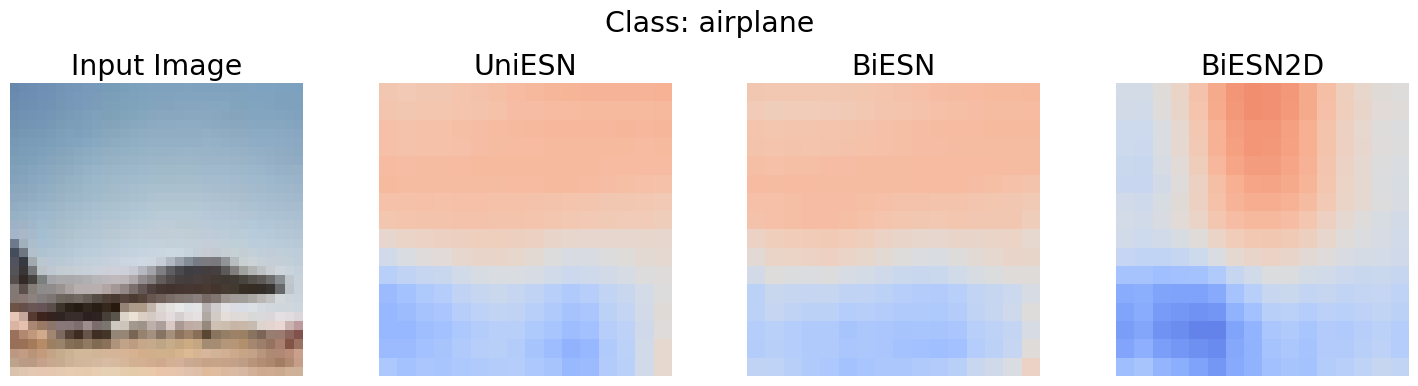

Class: automobile, Image shape: (32, 32, 3)
-0.008512863 0.042817928
-0.010421173 0.04267122
-0.008603857 0.060516443


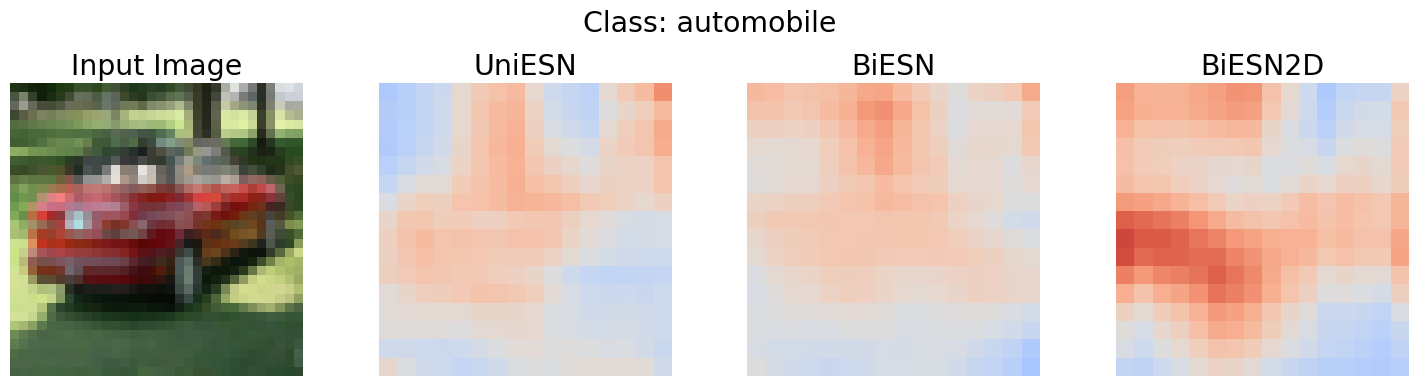

Class: bird, Image shape: (32, 32, 3)
-0.029324532 0.035886664
-0.018642884 0.040504076
-0.031828567 0.043325823


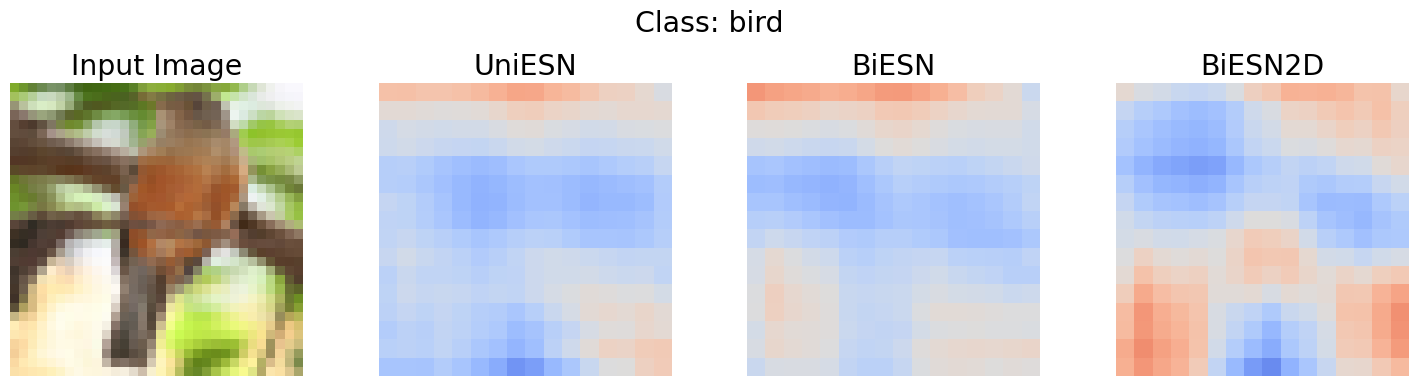

Class: cat, Image shape: (32, 32, 3)
-0.02559933 0.06444678
-0.0139352 0.06025249
-0.012097408 0.09059905


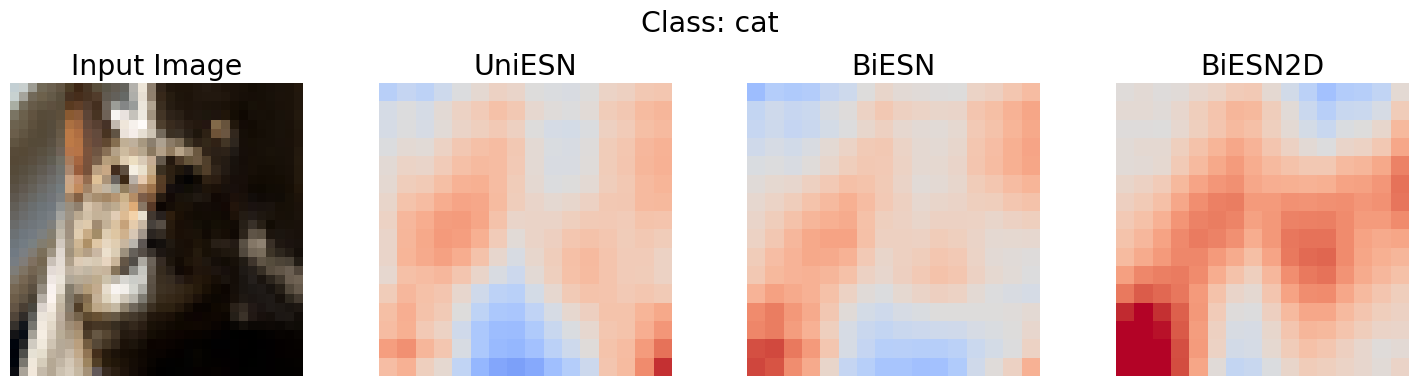

Class: deer, Image shape: (32, 32, 3)
-0.011040171 0.028815512
-0.010085916 0.03226626
-0.00050037703 0.052997388


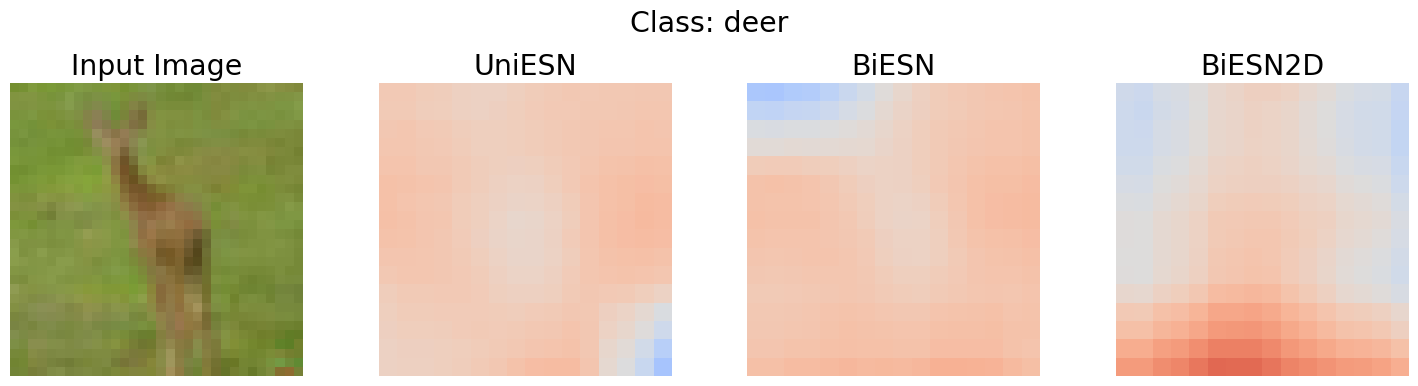

Class: dog, Image shape: (32, 32, 3)
-0.009472642 0.051141866
-0.022878768 0.04657112
-0.009438801 0.06534801


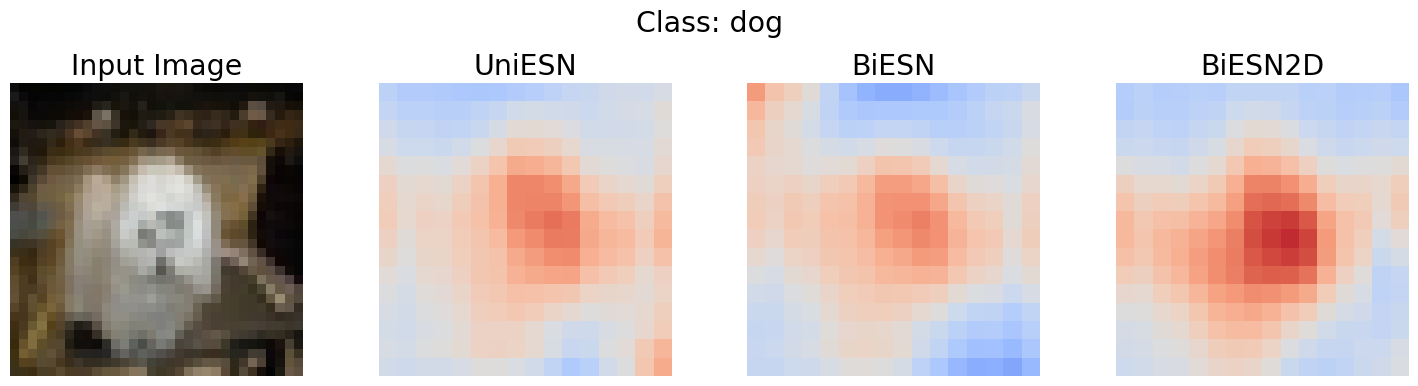

Class: frog, Image shape: (32, 32, 3)
-0.0026399414 0.02894372
-0.00052371225 0.031004487
-0.015010294 0.048542567


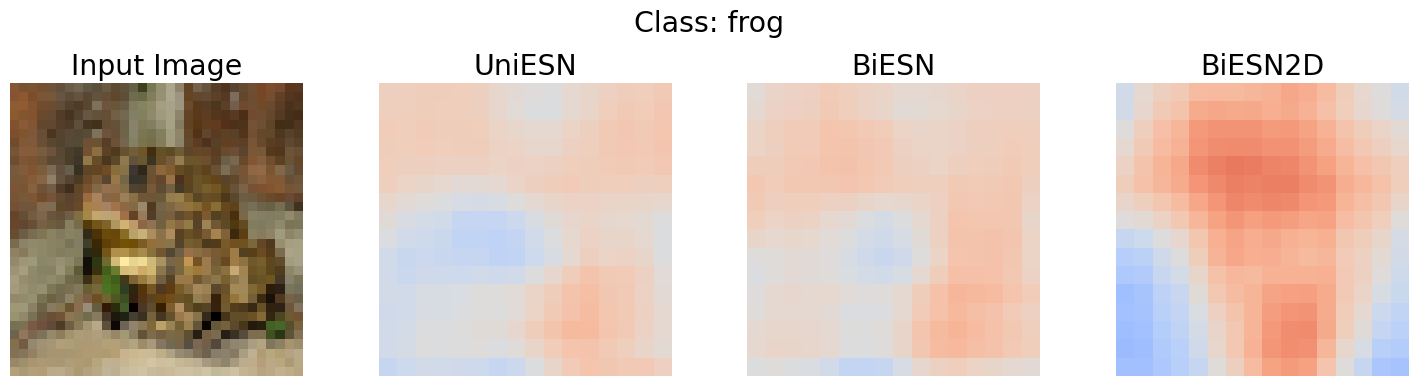

Class: horse, Image shape: (32, 32, 3)
-0.0038549274 0.048239376
-0.0045967344 0.061325096
-0.00938273 0.08474375


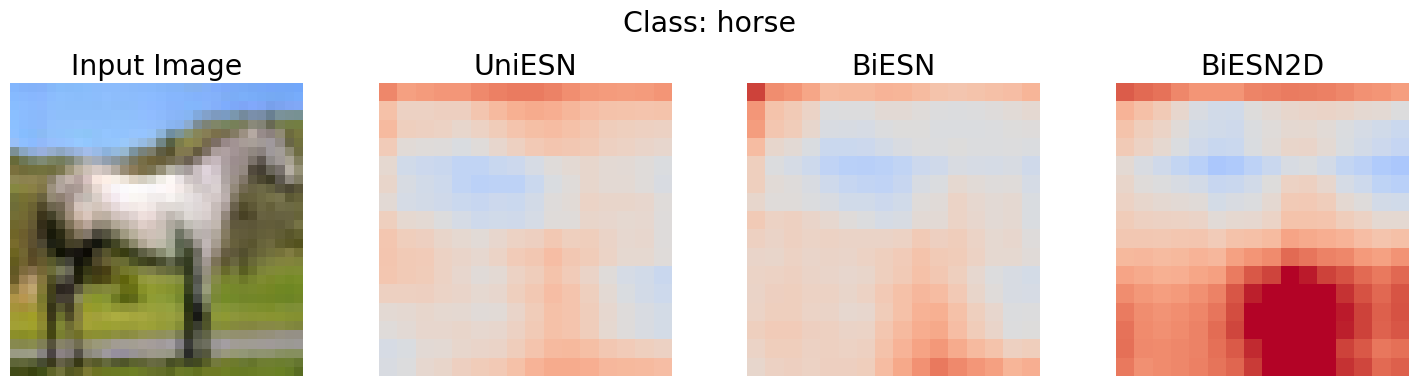

Class: ship, Image shape: (32, 32, 3)
-0.016431935 0.04538061
-0.0020913342 0.055462312
-0.0033096352 0.08400905


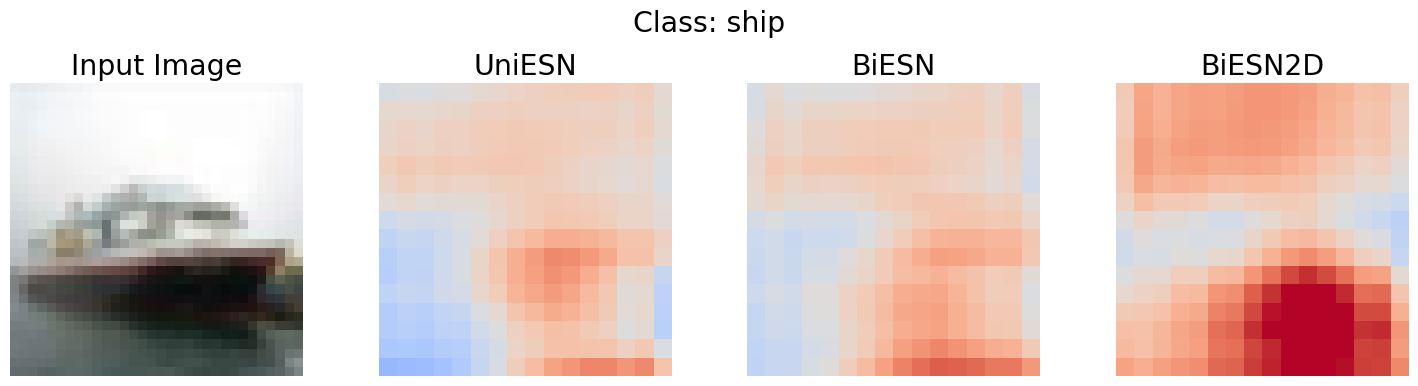

Class: truck, Image shape: (32, 32, 3)
0.0026856184 0.046176396
-0.009146138 0.057845768
-0.020729471 0.098146304


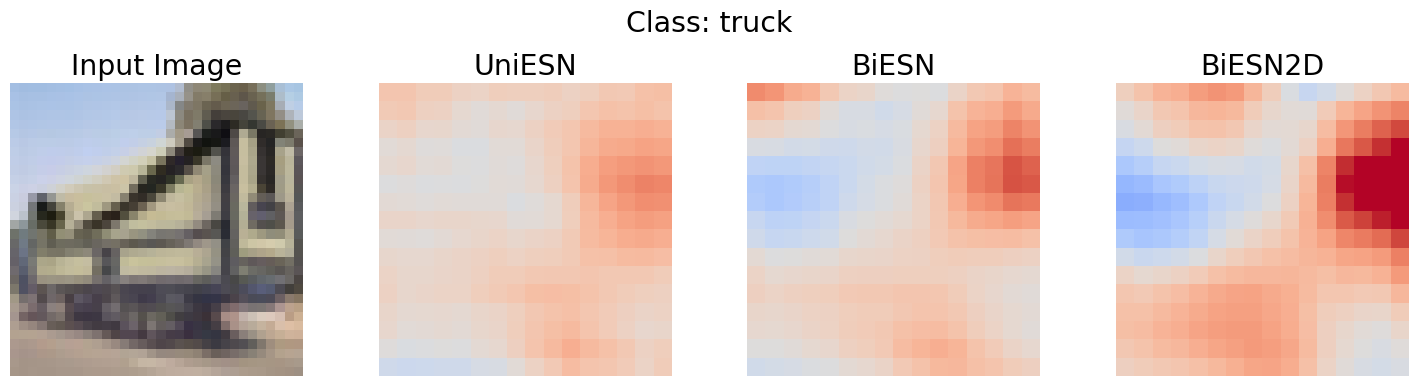

In [49]:
SAVE_PATH = "../results/nm2026_out/occ_maps"
os.makedirs(SAVE_PATH, exist_ok=True)

for i, inputs in enumerate(input_imgs):
    print(f"Class: {inputs[0]}, Image shape: {inputs[1].shape}")

    img = np.squeeze(inputs[1])  # (H, W) or (H, W, C)
    cmap = "gray" if img.ndim == 2 else "viridis"

    save_input_dir = os.path.join(SAVE_PATH, DATASET, "inputs")
    os.makedirs(save_input_dir, exist_ok=True)
    plt.imsave(os.path.join(save_input_dir, f"{inputs[0]}.png"), img, cmap=cmap, vmin=0, vmax=1)

    save_occ_dir = os.path.join(SAVE_PATH, DATASET, "occs")
    save_cmpr_dir = os.path.join(SAVE_PATH, DATASET, "compares")
    os.makedirs(save_occ_dir, exist_ok=True)
    os.makedirs(save_cmpr_dir, exist_ok=True)

    plt.figure(figsize=(15, 4))
    plt.suptitle(f"Class: {inputs[0]}")
    plt.subplot(1, 4, 1)
    plt.title("Input Image")
    plt.imshow(img, cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")

    for j, (model_name, maps) in enumerate(model_maps.items()):
        heat_map = maps[i][1]  # (H, W) or (H, W, C)

        print(heat_map.min(), heat_map.max())
        # VMIN = heat_map.min()  # ヒートマップの最小値を自動で取得
        # VMAX = heat_map.max()  # ヒートマップの最大値を自動で取得
        VMIN = -0.05
        VMAX = 0.07

        if heat_map.max() > VMAX or heat_map.min() < VMIN:
            print(f"Warning: min={heat_map.min():.4f}, max={heat_map.max():.4f}")

        plt.imsave(
            os.path.join(save_occ_dir, f"{inputs[0]}_{MODEL_CONVERTER[model_name]}.png"),
            heat_map,
            cmap="coolwarm",
            vmin=VMIN,
            vmax=VMAX,
        )

        plt.subplot(1, 4, j + 2)
        plt.title(f"{MODEL_CONVERTER[model_name]}")
        plt.imshow(heat_map, cmap="coolwarm", vmin=VMIN, vmax=VMAX)
        plt.axis("off")
    plt.tight_layout()

    plt.savefig(
        os.path.join(save_cmpr_dir, f"{inputs[0]}_comparison.png"), dpi=300, bbox_inches="tight", pad_inches=0.1
    )

    plt.show()

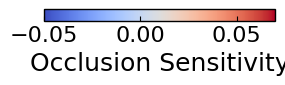

In [50]:
# カラーバーの作成

VMIN = -0.05
VMAX = 0.07

plt.figure(figsize=(6, 1))
plt.imshow([[VMIN, VMAX]], aspect="auto", cmap="coolwarm")
plt.gca().set_visible(False)
cbar = plt.colorbar(orientation="horizontal", pad=0.2)
cbar.set_label("Occlusion Sensitivity", fontsize=18)
cbar.ax.tick_params(labelsize=16)
plt.show()